# Options Pricing Project

### Setup

In [9]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

### Black-Scholes Derivation

We will begin with a derivation of the Black-Scholes equation, from now on abbreviated to BS. The key assumptions are:

- Constant volatility, $\sigma$
- Constant risk-free interest rate, $r$
- Stock prices follow a geometric Brownian motion (GBM)

Under these assumptions, we begin with modelling the stock price as a stochastic process. Since it follows A GBM, it must satisy the stochastic differential equation (SDE)
$$
dS = \mu S + \sigma S dB,
$$
where $\mu$ is some drift parameter. The value of an option, $V$, depends only on time and the stock price, thus $V=V(S,t)$. Applying Itô's lemma to $V$, we find that
$$
dV = \frac{\partial V}{\partial t} dt + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} dt + \frac{\partial V}{\partial S} dS
$$
Now, at the same time as doing this we shall consider a delta-hedged portfolio, $\Pi$, consisting of longing a single option and shorting $\Delta$ shares of the underlying stock. We thus have
$$
\Pi = V - \Delta S.
$$
It follows then that any incremental change in the portfolio's value is given by
$$
\begin{align*}
    d\Pi &= dV - \Delta dS \\
    & = \frac{\partial V}{\partial t} dt + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} dt + \frac{\partial V}{\partial S} dS - \Delta dS
\end{align*}
$$
The entire purpose of delta-hedging is to eliminate any dependency of the portfolio's value on changes in the underlying stock, thus it is necessary to choose $\Delta = \frac{\partial V}{\partial S}$ leaving us with
$$
d\Pi = \frac{\partial V}{\partial t} dt + \frac{1}{2}\sigma^2 S^2\frac{\partial^2 V}{\partial S^2} dt
$$
only. Now that we have eliminated any dependency on the underlying stock, the only change in the portfolio's value should be due to interest. We should thus have, for an incremental time step,
$$
d\Pi = r\Pi \, dt = rV \, dt - rS\frac{\partial V}{\partial S} dt.
$$
Equating these two separate expressions for $d\Pi$ yields
$$
\begin{align*}
    &rV \, dt - rS\frac{\partial V}{\partial S} dt = \frac{\partial V}{\partial t} dt + \frac{1}{2}\sigma^2 S^2\frac{\partial^2 V}{\partial S^2} dt \\
    \implies &rV = \frac{\partial V}{\partial t} + rS\frac{\partial V}{\partial S} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2},
\end{align*}
$$
and we have our desired result, the BS equation.

In the case of a call option with strike price $K$, the expected payoff at maturity is $\max{(S-K, 0)}$, thus we must impose the terminal condition $V(S,T) = \max{(S-K, 0)}$ where $T$ is the maturity date. We also require that $V(0,t)=0$ for all $t$ since a stock of no value cannot grow under a GBM. Similarly, we impose the far field condition $\lim_{S\rightarrow \infty}V = S-Ke^{-r(T-t)}$ since for sufficiently large stock prices, the option will almost certainly be exercised.

### Transformation to Heat Equation

The BS equation does, in fact, have an analytical solution. To see this, we use the substitution
$$
\tau = \frac{\sigma^2}{2}(T-t), \quad x = \ln\bigg(\frac{S}{K}\bigg) + \bigg(r-\frac{\sigma^2}{2}\bigg)(T-t), \quad u(x, \tau) = Ve^{2r\tau/\sigma^2}.
$$
By the chain rule, we have
$$
\begin{align*}
    \frac{\partial}{\partial t} &= \frac{\partial x}{\partial t}\frac{\partial}{\partial x} + \frac{\partial \tau}{\partial t}\frac{\partial}{\partial \tau} = \bigg(\frac{\sigma^2}{2} - r\bigg)\frac{\partial}{\partial x} - \frac{\sigma^2}{2}\frac{\partial}{\partial \tau}, \\
    \frac{\partial}{\partial S} &= \frac{\partial x}{\partial S}\frac{\partial}{\partial x} + \frac{\partial \tau}{\partial S}\frac{\partial}{\partial \tau} = \frac{1}{S}\frac{\partial}{\partial x}.
\end{align*}
$$
We may thus rewrite the BS equation as
$$
\begin{align*}
    rue^{-2r\tau/\sigma^2} &= \bigg(\frac{\sigma^2}{2} - r\bigg)\frac{\partial (ue^{-2r\tau/\sigma^2})}{\partial x} - \frac{\sigma^2}{2}\frac{\partial (ue^{-2r\tau/\sigma^2})}{\partial \tau} + r \frac{\partial (ue^{-2r\tau/\sigma^2})}{\partial x} + \frac{\sigma^2 S}{2}\frac{\partial}{\partial x}\bigg( \frac{1}{S}\frac{\partial (ue^{-2r\tau /\sigma^2})}{\partial x}\bigg) \\

    rue^{-2r\tau/\sigma^2} &= e^{-2r\tau/\sigma^2}\bigg(\frac{\sigma^2}{2} - r\bigg)\frac{\partial u}{\partial x} - e^{-2r\tau/\sigma^2}\frac{\sigma^2}{2}\frac{\partial u}{\partial \tau} + rue^{-2r\tau/\sigma^2} + re^{-2r\tau/\sigma^2} \frac{\partial u}{\partial x} - e^{-2r\tau/\sigma^2}\frac{\sigma^2}{2}\frac{\partial u}{\partial x} + e^{-2r\tau/\sigma^2}\frac{\sigma^2}{2}\frac{\partial^2u}{\partial x^2} \\

    \frac{\partial u}{\partial \tau}  &=  \frac{\partial^2u}{\partial x^2},
\end{align*}
$$
which we recognise as the well-known heat equation. The corresponding transformed boundary conditions are
$$
\lim_{x\rightarrow -\infty} u(x,\tau) = 0 \\
\lim_{x\rightarrow \infty} = K(e^{x+\tau}-1) \\
u(x,0) = K(e^x-1)H(x) 
$$
where $H(x)$ is the Heaviside step function.


### Analytical Solution

Since this heat equation is defined on an unbounded spatial domain, we use the standard method of taking the convolution of the initial condition with the fundamental solution of the heat equation. In the 1D case, as applies here, we have
$$
\begin{align*}
    u(x, \tau) &= \frac{1}{(4\pi\tau)^{\frac{1}{2}}} \int_{-\infty}^\infty K(e^y-1)H(y)e^{-\frac{(x-y)^2}{4\tau}} dy \\
    &= \frac{K}{(4\pi\tau)^{\frac{1}{2}}} \int_0^\infty (e^y-1) e^{-\frac{(x-y)^2}{4\tau}} dy \\
    &= \frac{K}{(4\pi\tau)^{\frac{1}{2}}} \bigg( I_1 - I_2\bigg)
\end{align*}
$$
where $I_1=\int_0^\infty e^{y-\frac{(x-y)^2}{4\tau}} dy$ and $I_2 = \int_0^\infty e^{-\frac{(x-y)^2}{4\tau}} dy$. We compute these integrals in turn. By completing the square in the exponent we have
$$
\begin{align*}
    I_1 &= \int_0^\infty \exp\bigg(\frac{4\tau y - x^2 - y^2 +2xy}{4\tau}\bigg) dy \\
    &= e^{\tau + x}\int_0^\infty \exp\bigg(-\frac{(y-(2\tau+x))^2}{4\tau}\bigg) dy.
\end{align*}
$$
The substitution $z=\frac{y-(2\tau+x)}{\sqrt{2\tau}}$ yields
$$
\begin{align*}
    I_1 &= \sqrt{2\tau} e^{\tau + x} \int_{-\frac{2\tau + x}{\sqrt{2\tau}}}^\infty e^{-\frac{z^2}{2}} dz \\
    &= \sqrt{4\pi\tau} e^{\tau + x} \Phi\bigg(\frac{2\tau + x}{\sqrt{2\tau}}\bigg),
\end{align*}
$$
where $\Phi$ is the CDF of a standard normal random variable and the last line follows from the symmetry of a standard normal distribution about $0$. The remaining integral is computed using the substitution $z=\frac{x-y}{\sqrt{2\tau}}$ which yields
$$
I_2 = -\sqrt{2\tau}\int_{\frac{x}{\sqrt{2\tau}}}^{-\infty} e^{-\frac{z^2}{2}} dz = \sqrt{4\pi\tau}\Phi\bigg(\frac{x}{\sqrt{2\pi}}\bigg).
$$
Again, the last equality follows from the symmetrical properties of a standard normal PDF. Combining these results we see that
$$
u(x,\tau) = K\Bigg( e^{\tau+x}\Phi\bigg(\frac{2\tau + x}{\sqrt{2\tau}}\bigg) - \Phi\bigg(\frac{x}{\sqrt{2\pi}}\bigg)\Bigg).
$$
In terms of the original variables, this is
$$
V(S,t) = S\Phi\bigg(\frac{\ln(\frac{S}{K})+(r+\frac{\sigma^2}{2})(T-t)}{\sigma \sqrt{T-t}} \bigg) - e^{-r(T-t)}\Phi\bigg(\frac{\ln(\frac{S}{K}) + (r-\frac{\sigma^2}{2})(T-t)}{\sigma\sqrt{T-t}} \bigg),
$$
which is our desired analytic solution to the BS equation.

We will now plot a collection of solutions for various values of $K, r, \sigma, T$.

C:\Users\ccbar\AppData\Local\Temp\ipykernel_18856\982528526.py:13: RuntimeWarning: divide by zero encountered in divide
  a = (np.log(S/K) + (r+sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)
C:\Users\ccbar\AppData\Local\Temp\ipykernel_18856\982528526.py:13: RuntimeWarning: invalid value encountered in divide
  a = (np.log(S/K) + (r+sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)
C:\Users\ccbar\AppData\Local\Temp\ipykernel_18856\982528526.py:14: RuntimeWarning: divide by zero encountered in divide
  b = (np.log(S/K) + (r-sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)
C:\Users\ccbar\AppData\Local\Temp\ipykernel_18856\982528526.py:14: RuntimeWarning: invalid value encountered in divide
  b = (np.log(S/K) + (r-sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)


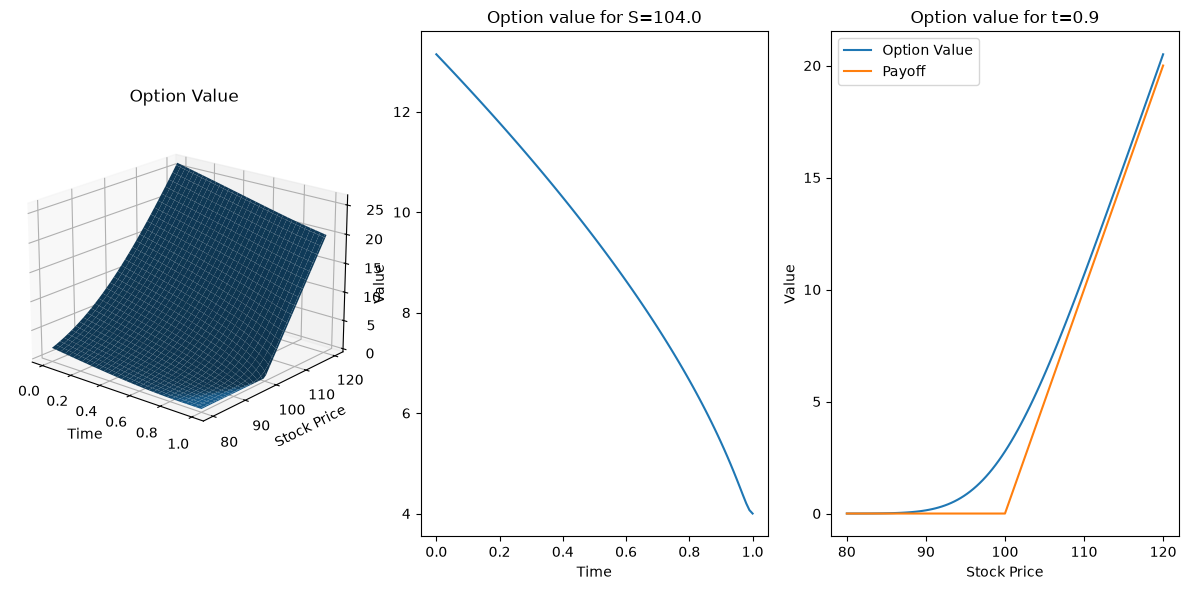

In [ ]:
# Initialise variables
T = 1
K = 100
r = 0.05
sigma = 0.2

# Create the time and stock domain
t = np.linspace(0,T,101)
S = np.linspace(80,120,101)
t, S = np.meshgrid(t, S)

# For readibility, we will define the terms inside the normal CDF
a = (np.log(S/K) + (r+sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)
b = (np.log(S/K) + (r-sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)

V = S * sp.stats.norm.cdf(a) - K * np.exp(-r*(T-t)) * sp.stats.norm.cdf(b)

fig = plt.figure(figsize=(12,6))

ax1 = fig.add_subplot(1, 3, 1, projection='3d')
ax1.plot_surface(t, S, V)
ax1.set_title('Option Value')
ax1.set_xlabel('Time')
ax1.set_ylabel('Stock Price')
ax1.view_init(elev=20, azim=-50)

ax2 = fig.add_subplot(1,3,2)
ax2.plot(t[0], V[60,:])
ax2.set_title(f'Option value for S={S[60,0]}')
ax2.set_xlabel('Time')
ax2.set_ylabel('Value')

ax3 = fig.add_subplot(1,3,3)
ax3.plot(S[:,0], V[:, 90])
ax3.plot(S[:,0], np.maximum(S[:,0]-K, 0))
ax3.set_title(f'Option value for t={t[0,90]}')
ax3.set_xlabel('Stock Price')
ax3.set_ylabel('Value')
ax3.legend(['Option Value', 'Payoff'])

plt.tight_layout()
plt.show()

### Crank-Nicholson Solver

In [56]:
T = 1
K = 100
r = 0.05
sigma = 0.2

m=1000
n=10000
S_upper = 400
dS = S_upper/m
dt = T/n

# Initialise matrix as 0s. This also takes care of the first boundary condition.
V = np.zeros((m+1,n+1))

# Terminal condition
V[:,n] = np.maximum([i*dS-K for i in np.arange(m+1)], 0)

# Far-field condition
V[m, :] = [ S_upper - K*np.exp(-r*(T-j*dt)) for j in range(n+1) ]

# Define our matrix A
lower = np.array([ dt*i*(r - i*(sigma**2)) for i in range(2,m) ])
main = np.array([ 4+2*dt*(r+(i**2)*sigma**2) for i in range(1,m) ])
upper = np.array([ -dt*i*(r + i*(sigma**2)) for i in range(1,m-1) ])
A = sp.sparse.diags([lower, main, upper], offsets=(-1,0,1), format='csc')

# Define our matrix D
lower = -lower
main = np.array([ 4-2*dt*(r+(i**2)*sigma**2) for i in range(1,m) ])
upper = -upper
D = sp.sparse.diags([lower, main, upper], offsets=(-1,0,1), format='csc')

# Start loop
for j in range(n):
    # Compute the RHS of the matrix equation.
    d = D @ V[1:m, n-j]

    # In order to apply the boundary condition we must update the last entry of d
    #d[m-2] += dt*(m-1)*(1+m*sigma**2-sigma**2)*(2*S_upper - K*np.exp(-r*(T-(n-j-1)*dt))*(np.exp(r*dt)+1)  )

    d[m-2] += dt*(m-1)*((m-1)*sigma**2 + r)*(V[m, n-j] + V[m, n-j-1])

    # V has dimensions m+1 x n+1 whereas A has dimensions m x m. We initialised V to be zeros so the first row does not need changing.
    V[1:m, n-j-1] = sp.sparse.linalg.spsolve(A, d)




C:\Users\ccbar\AppData\Local\Temp\ipykernel_812\2158699531.py:7: RuntimeWarning: divide by zero encountered in log
  a = (np.log(S/K) + (r+sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)
C:\Users\ccbar\AppData\Local\Temp\ipykernel_812\2158699531.py:7: RuntimeWarning: divide by zero encountered in divide
  a = (np.log(S/K) + (r+sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)
C:\Users\ccbar\AppData\Local\Temp\ipykernel_812\2158699531.py:7: RuntimeWarning: invalid value encountered in divide
  a = (np.log(S/K) + (r+sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)
C:\Users\ccbar\AppData\Local\Temp\ipykernel_812\2158699531.py:8: RuntimeWarning: divide by zero encountered in log
  b = (np.log(S/K) + (r-sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)
C:\Users\ccbar\AppData\Local\Temp\ipykernel_812\2158699531.py:8: RuntimeWarning: divide by zero encountered in divide
  b = (np.log(S/K) + (r-sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)
C:\Users\ccbar\AppData\Local\Temp\ipykernel_812\2158699531.py:8: RuntimeWarning: invalid value encountered 

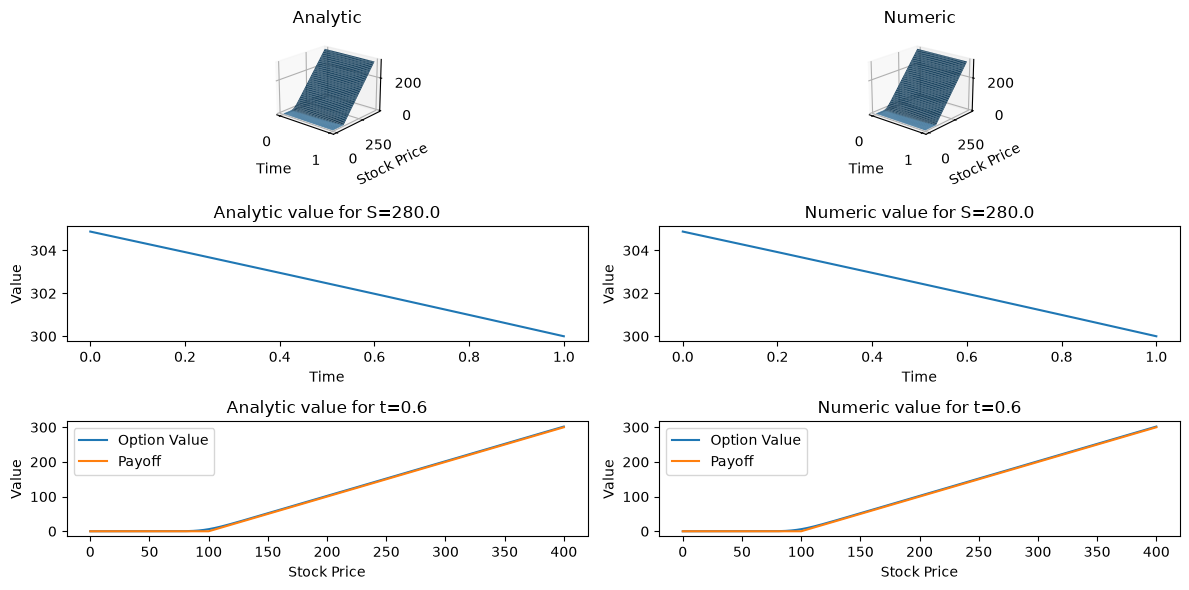

In [58]:
# Create the time and stock domain
t = np.linspace(0,T,n+1)
S = np.linspace(0,S_upper,m+1)
t, S = np.meshgrid(t, S)

# For readibility, we will define the terms inside the normal CDF
a = (np.log(S/K) + (r+sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)
b = (np.log(S/K) + (r-sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)

V_analytic = S * sp.stats.norm.cdf(a) - K * np.exp(-r*(T-t)) * sp.stats.norm.cdf(b)


fig = plt.figure(figsize=(12,6))

ax1 = fig.add_subplot(3, 2, 1, projection='3d')
ax1.plot_surface(t, S, V_analytic)
ax1.set_title('Analytic')
ax1.set_xlabel('Time')
ax1.set_ylabel('Stock Price')
ax1.view_init(elev=20, azim=-50)

ax2 = fig.add_subplot(3, 2, 2, projection='3d')
ax2.plot_surface(t, S, V)
ax2.set_title('Numeric')
ax2.set_xlabel('Time')
ax2.set_ylabel('Stock Price')
ax2.view_init(elev=20, azim=-50)

ax3 = fig.add_subplot(3,2,3)
ax3.plot(t[0], V_analytic[int(1.*m),:])
ax3.set_title(f'Analytic value for S={S[int(0.7*m),0]}')
ax3.set_xlabel('Time')
ax3.set_ylabel('Value')

ax4 = fig.add_subplot(3,2,4)
ax4.plot(t[0], V[int(1.*m),:])
ax4.set_title(f'Numeric value for S={S[int(0.7*m),0]}')
ax4.set_xlabel('Time')
ax4.set_ylabel('Value')

ax5 = fig.add_subplot(3,2,5)
ax5.plot(S[:,0], V_analytic[:, int(0.6*n)])
ax5.plot(S[:,0], np.maximum(S[:,0]-K, 0))
ax5.set_title(f'Analytic value for t={t[0,int(0.6*n)]}')
ax5.set_xlabel('Stock Price')
ax5.set_ylabel('Value')
ax5.legend(['Option Value', 'Payoff'])

ax6 = fig.add_subplot(3,2,6)
ax6.plot(S[:,0], V[:, int(0.6*n)])
ax6.plot(S[:,0], np.maximum(S[:,0]-K, 0))
ax6.set_title(f'Numeric value for t={t[0,int(0.6*n)]}')
ax6.set_xlabel('Stock Price')
ax6.set_ylabel('Value')
ax6.legend(['Option Value', 'Payoff'])

plt.tight_layout()
plt.show()

In [43]:
V.shape

(1001, 10001)

### Convergence Analysis

### Greeks Calculation

### Comparison With Market Data